In [1]:

import os
import pandas as pd
import numpy as np
from scipy.spatial import cKDTree
import matplotlib.pyplot as plt
import re

/home/robertbre/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


**TODO**:
- Mät tiden från running till stop [OK]
- Byt stoppunkt vid teckenskifte [OK]
 
**CCRs**:
- Hur väl/konsekvent följer Mondeon trajen [Samuel]
- Stoppunkt varians [OK]
- Praktiskt offset vs open scenario (25%*2m) [Robert]

**CBLA**:
- Vid vilken tidpunkt når mondeon stopppunkten (t0 valt vid armed->running).

**Saker att tänka på**:
- Är vi säkra på att ATOS följer ISO-spec när den skickar ut position.
- Mondeo offset?

In [2]:
def log_to_df(file_path) -> pd.DataFrame:
  columns = [
    "timestamp", "client_id", "client_ip", "x", "y", "z", 
    "yaw", "speed_lon", "speed_lat", "acc_lon", "acc_lat", 
    "driving_dir", "ready", "error_status"
	]
 
  pattern = re.compile(
    r"^\d+\.\d+: \d+\.\d+;\d+;(?:\d{1,3}\.){3}\d{1,3};"
    r"[+-]?\d+\.\d+;[+-]?\d+\.\d+;[+-]?\d+\.\d+;"  # Coordinates and numeric fields
    r"[+-]?\d+\.\d+;[+-]?\d+\.\d+;[+-]?\d+\.\d+;"  # Speeds and accelerations
    r"(?:[+-]?\d+\.\d+|[a-zA-Z_]+);"              # Acceleration 1: number or string
    r"(?:[+-]?\d+\.\d+|[a-zA-Z_]+);"              # Acceleration 2: number or string
    r"[a-zA-Z_]+;"                                # Driving direction (e.g., NaN)
    r"[a-zA-Z_]+;"                                # Ready status (e.g., ARMED)
    r"[a-zA-Z_]+;"                                # Error status (e.g., NOT_READY_TO_ARM)
    r"[a-zA-Z_]+;$"                               # Final status (e.g., OK)
)
  
  data = []
  with open(file_path, "r") as file:
    for line in file:
      if pattern.match(line.strip()):
        relevant_part = line.split(":", 1)[1].strip()
        values = relevant_part.split(";")
        values = values[:14]
        data.append(values)
    
  df = pd.DataFrame(data, columns=columns)
  df['timestamp'] = df['timestamp'].apply(pd.to_numeric, errors="coerce")
  df['client_id'] = df['client_id'].apply(pd.to_numeric, errors="coerce")
  df['x'] = df['x'].apply(pd.to_numeric, errors="coerce")
  df['y'] = df['y'].apply(pd.to_numeric, errors="coerce")
  df['z'] = df['z'].apply(pd.to_numeric, errors="coerce")
  df['yaw'] = df['yaw'].apply(pd.to_numeric, errors="coerce")
  df['speed_lon'] = df['speed_lon'].apply(pd.to_numeric, errors="coerce")
  df['speed_lat'] = df['speed_lat'].apply(pd.to_numeric, errors="coerce")
  df['acc_lon'] = df['acc_lon'].apply(pd.to_numeric, errors="coerce")
  df['acc_lat'] = df['acc_lat'].apply(pd.to_numeric, errors="coerce")
  return df

In [45]:
def get_atos_traj(file_path):
  columns = ['x', 'y']
  
  pattern = r'x:([-+]?\d*\.\d+|\d+), y:([-+]?\d*\.\d+|\d+)'
  
  data = []
  with open(file_path, "r") as file:
    for line in file:
      match = re.search(pattern, line)
      if match:
        x = float(match.group(1))
        y = float(match.group(2))
        data.append((x, y))
  return pd.DataFrame(data, columns=columns)
      

In [64]:
def plot_obj_trajs(df, ax_position, color):

  start_time = df['timestamp'][df['speed_lon'] > 0.1].iloc[0]
  start_timestamp_index = df[df['timestamp'] == start_time].index[0]

  last_quarter = df['speed_lon'][int(len(df) * 0.75):]
  # Get idx where the positive to negative transition happens
  stopping_timestamp_index = np.where(np.diff(np.sign(last_quarter)))[0][0] + int(len(df) * 0.75)

  ax_position.plot(df['x'][start_timestamp_index:stopping_timestamp_index], df['y'][start_timestamp_index:stopping_timestamp_index], color)
  ax_position.set_title('Positions ISO-coordinates')
  ax_position.set_xlabel('x [m]')
  ax_position.set_ylabel('y [m]')

In [56]:
def plot_velocities(df, ax_velocity, offset_start=False):
  # start_time_idx = 0
  if offset_start:
    # Find the first time the vehicle moves above 0.05 m/s
    start_time = df['timestamp'][df['speed_lon'] > 0.1].iloc[0]
    start_time_idx = df[df['timestamp'] == start_time].index[0]
  else:
    start_time = df['timestamp'][0]
  duration = df['timestamp'].apply(lambda x: x - start_time)

  ax_velocity.plot(duration, df['speed_lon'])

  last_quarter = df['speed_lon'][int(len(df) * 0.75):]
  idx = np.where(np.diff(np.sign(last_quarter)))[0][0] + int(len(df) * 0.75)
  stop_velocity = last_quarter[idx]
  stop_velocity_timestamp = duration[idx]
  
  ax_velocity.scatter(stop_velocity_timestamp, stop_velocity, color='red', s=100, label='Stop')
  ax_velocity.scatter(duration[0], df['speed_lon'][0], color='black', s=100, marker='|', label='Start')
  ax_velocity.set_title('Velocity Profile')
  ax_velocity.set_xlabel('Time [s]')
  ax_velocity.set_ylabel('Speed [m/s]')
  return ax_velocity

In [6]:
def offset_traj(traj, offset, angle): 
    offset_traj_df = pd.DataFrame(columns=['x', 'y']) 
    x_offset = offset * np.cos(np.deg2rad(angle)) 
    y_offset = offset * np.sin(np.deg2rad(angle)) 
    offset_traj_df['x'] = traj['x'] + x_offset 
    offset_traj_df['y'] = traj['y'] + y_offset 
    return offset_traj_df

In [7]:
def get_stopping_position(df):
  last_quarter = df['speed_lon'][int(len(df) * 0.75):]
  # Get idx where the positive to negative transition happens
  idx = np.where(np.diff(np.sign(last_quarter)))[0][0] + int(len(df) * 0.75)

  x = df.loc[idx, 'x']
  y = df.loc[idx, 'y']
  timestamp = df.loc[idx, 'timestamp']
  return x, y, timestamp

In [8]:
def get_average_distance_vehicle_to_path(df_vehicle, df_traj):
  traj_tree = cKDTree(df_traj[['x', 'y']].values)
  distances, _ = traj_tree.query(df_vehicle[['x', 'y']].values)
  
  return np.mean(distances)

CCRs Logs 

['CCRs_0_280_traj_points', 'CCRs_25_280_traj_points', 'CCRs_50_280_traj_points']
Test: CCRs_0_280_traj_points
Mean stopping position [m]: (-6.48, -21.85) 	 Standard deviation: (0.01, 0.01)
	 Distance to last traj point: 1.11
Mean test duration [s]: 14.73 			 Standard deviation: 0.12
Mean distance to path [m]: 0.86 		 Standard deviation: 0.02
Scenario offset [m]: -0.0
Scenario offset error [m]: 0.00

Test: CCRs_25_280_traj_points
Mean stopping position [m]: (-6.68, -22.33) 	 Standard deviation: (0.03, 0.02)
	 Distance to last traj point: 1.13
Mean test duration [s]: 14.75 			 Standard deviation: 0.11
Mean distance to path [m]: 0.84 		 Standard deviation: 0.01
Scenario offset [m]: -0.5
Scenario offset error [m]: 0.02

Test: CCRs_50_280_traj_points
Mean stopping position [m]: (-6.78, -22.82) 	 Standard deviation: (0.02, 0.02)
	 Distance to last traj point: 1.10
Mean test duration [s]: 14.82 			 Standard deviation: 0.13
Mean distance to path [m]: 0.82 		 Standard deviation: 0.01
Scenario o

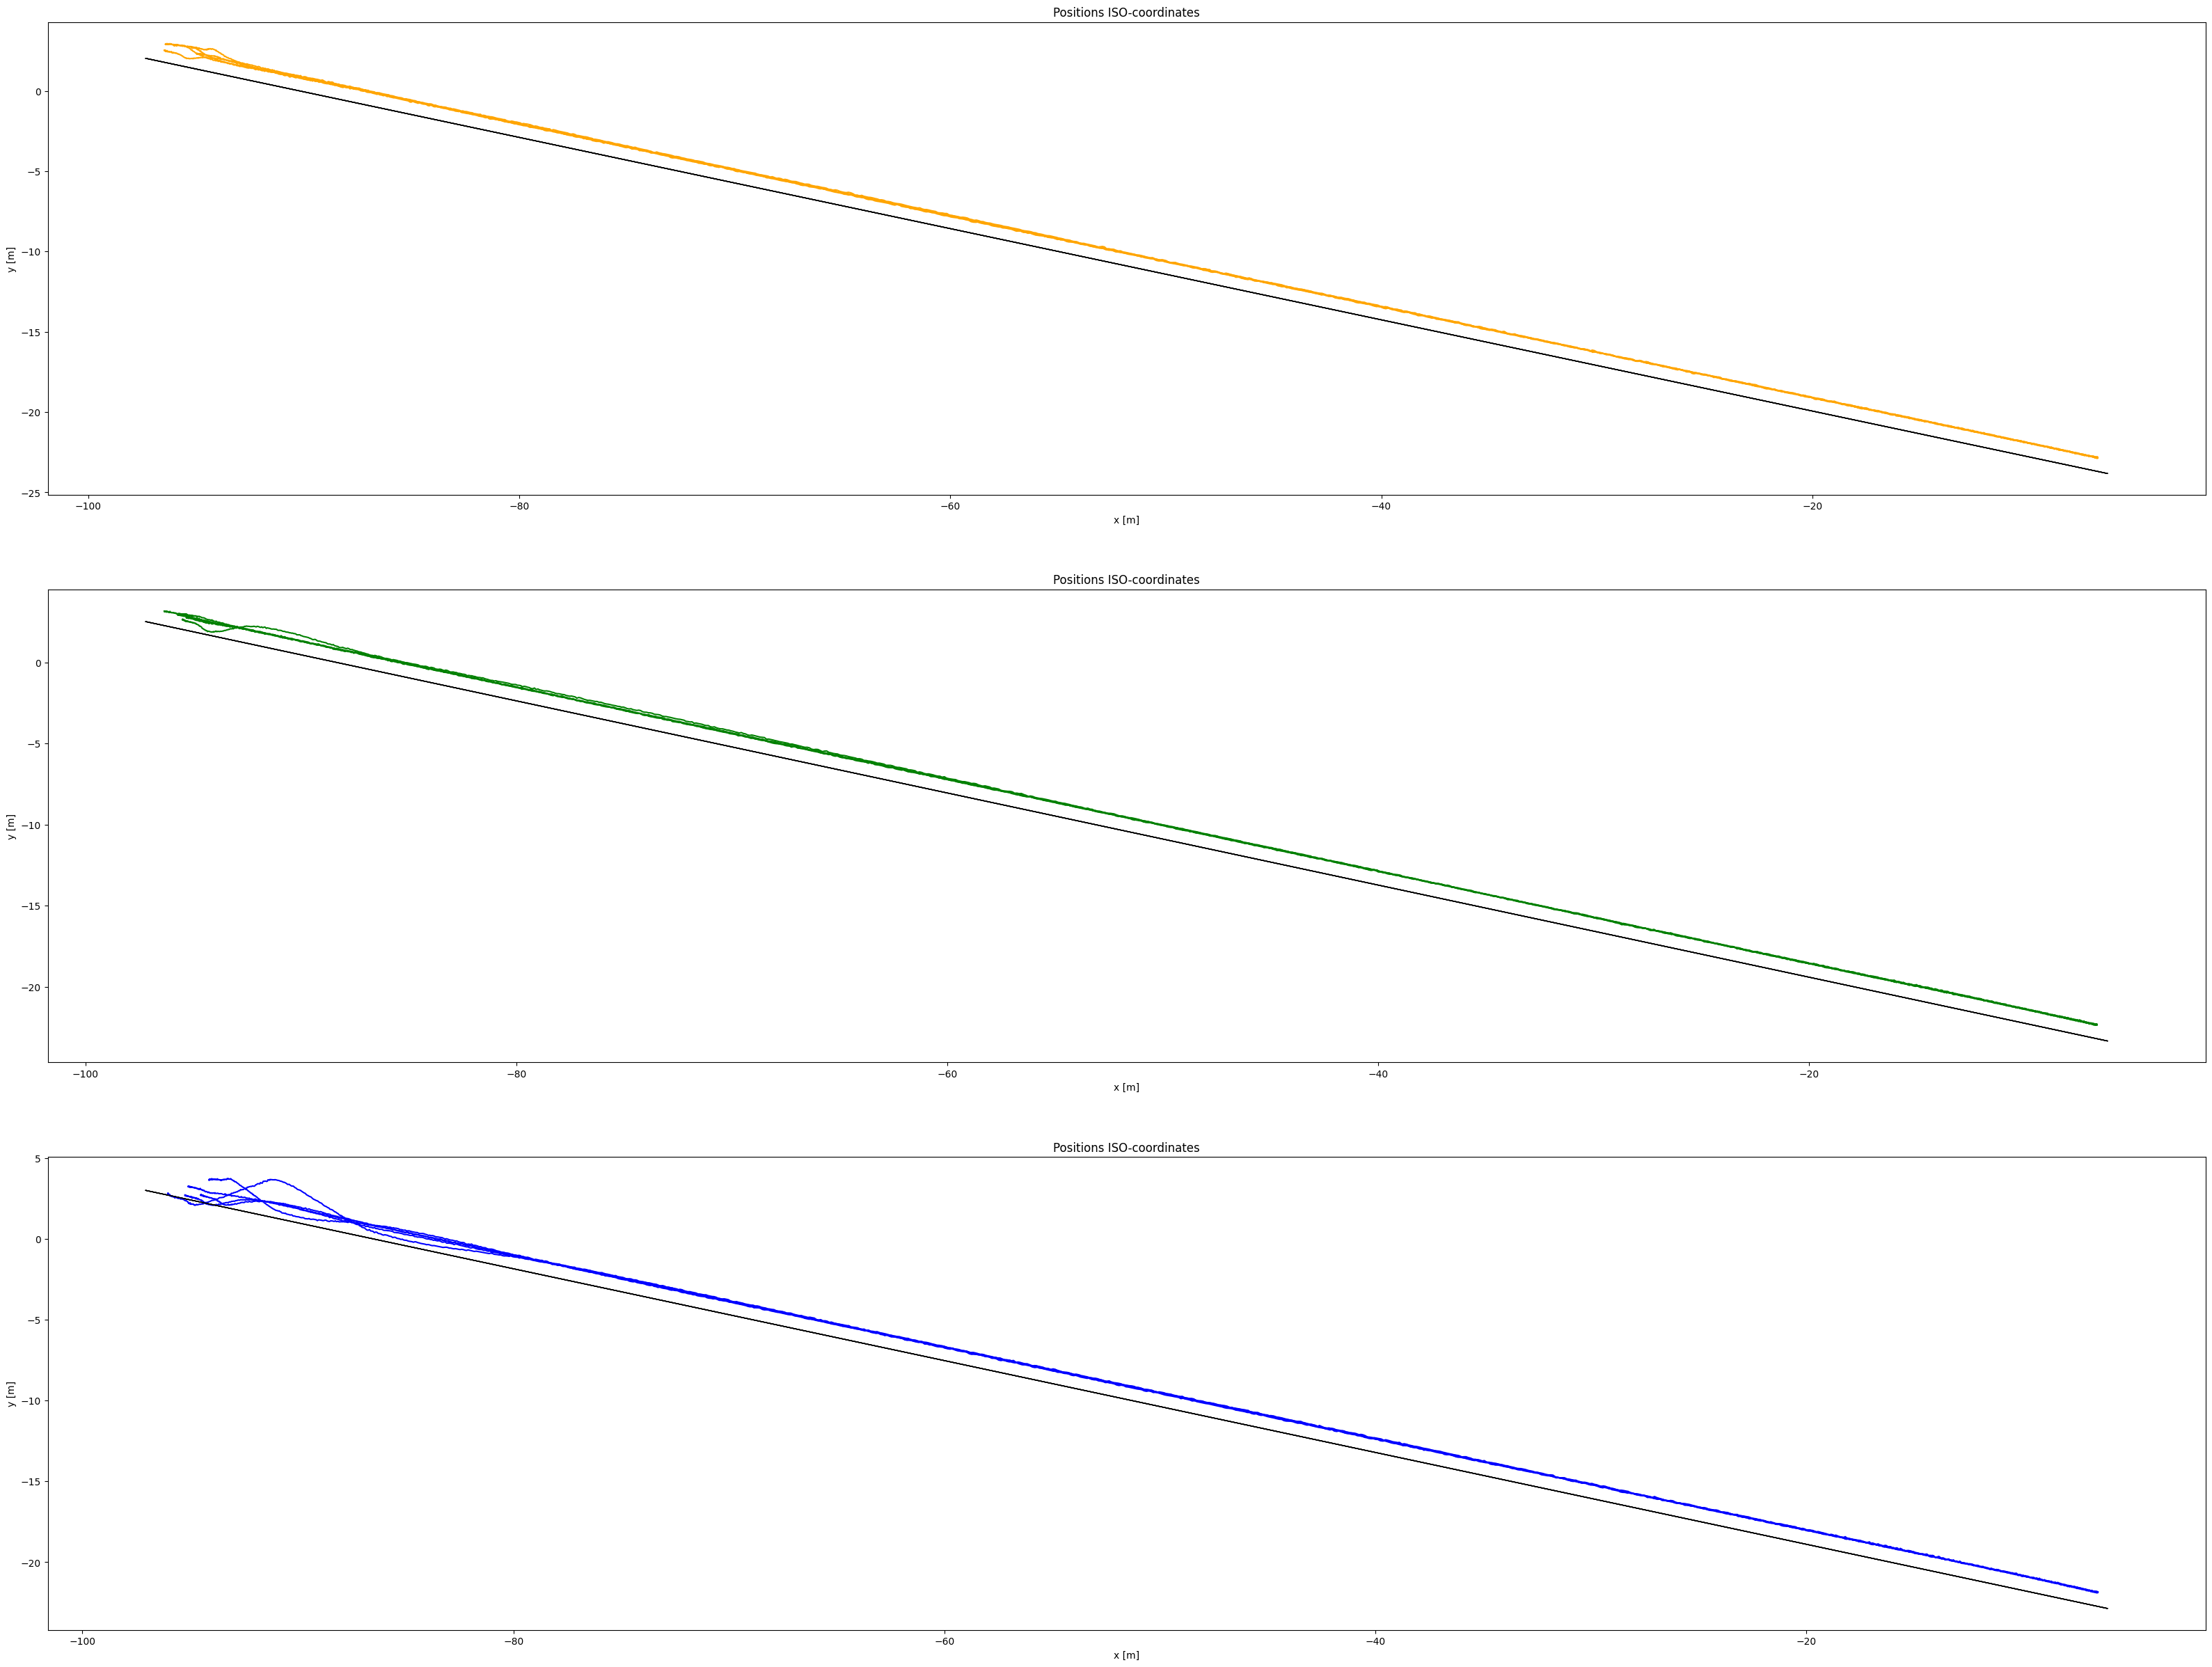

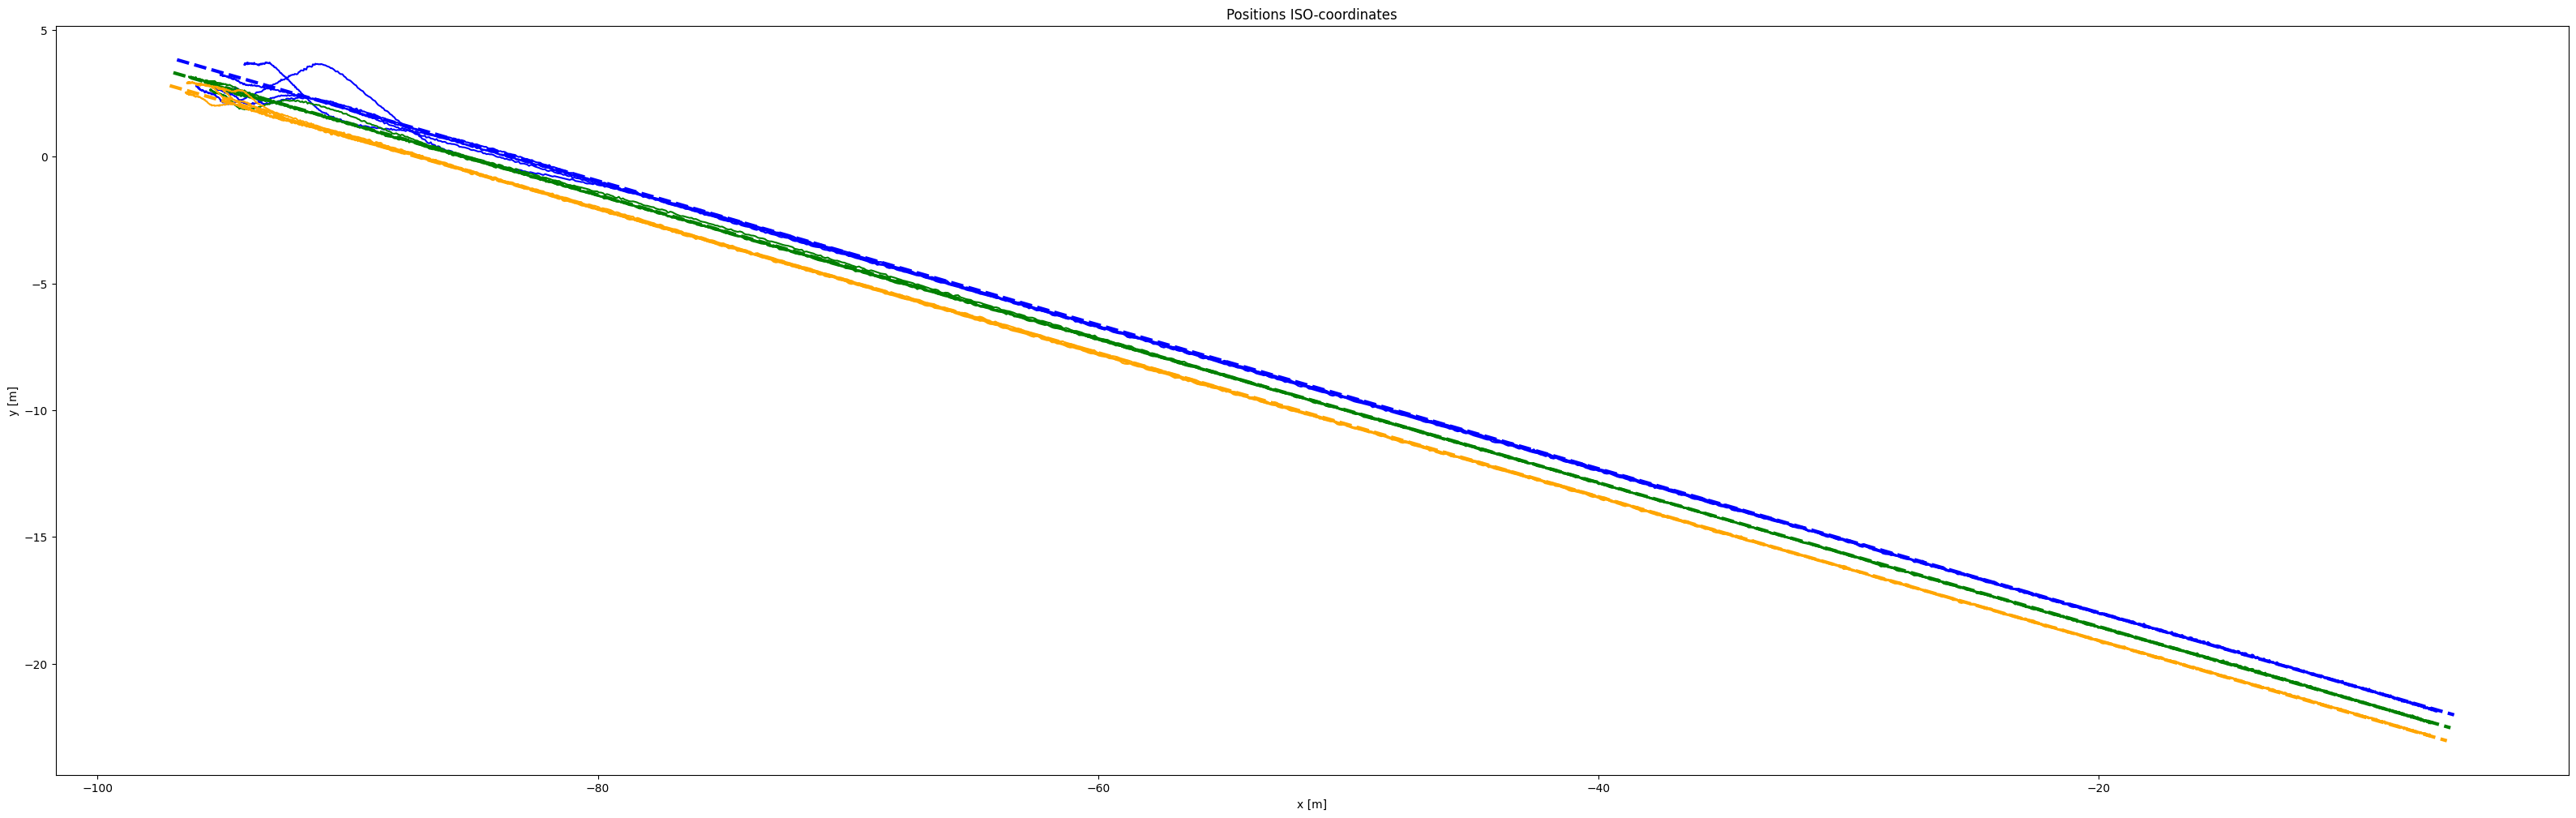

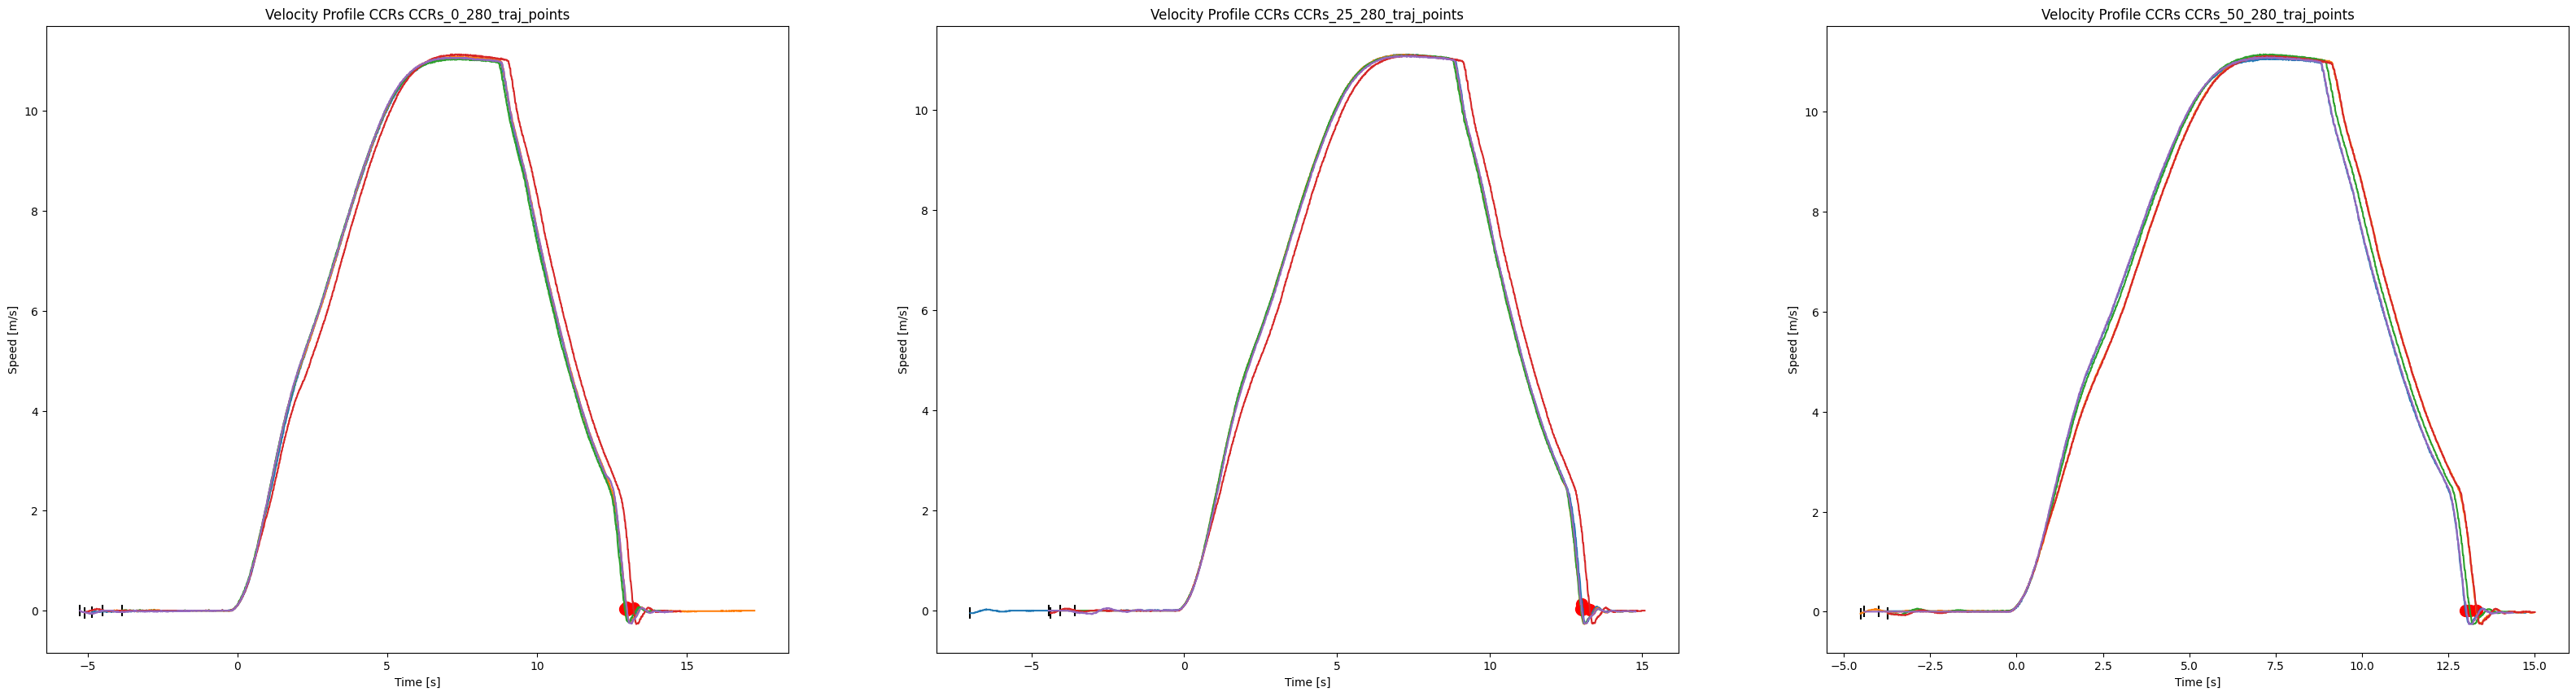

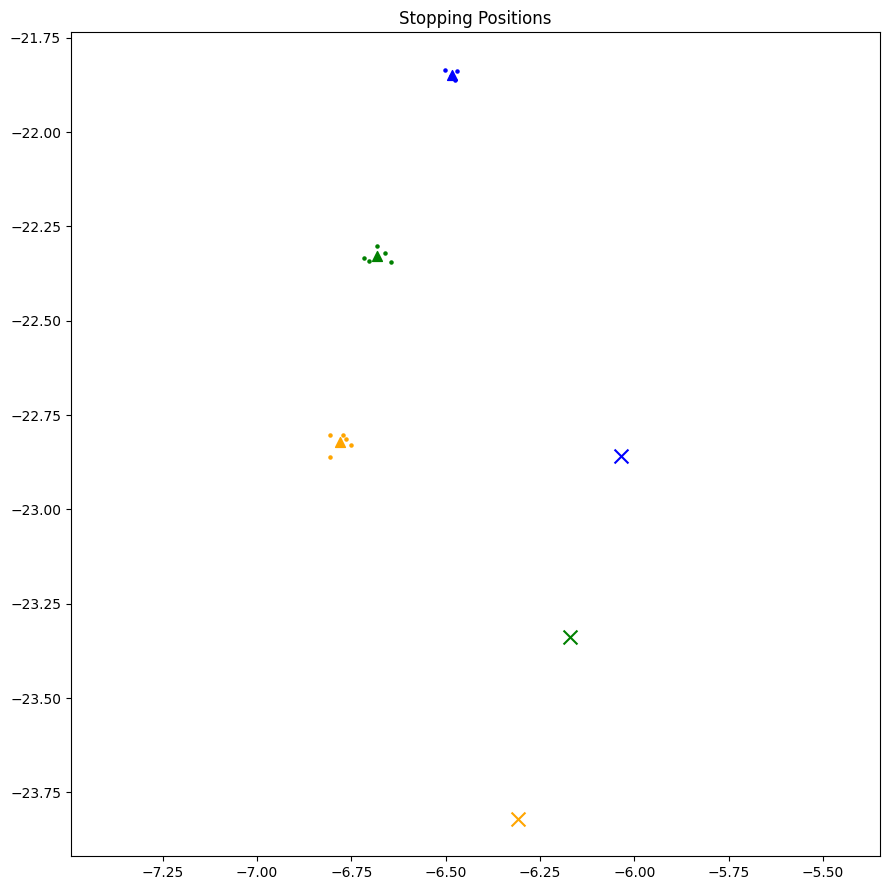

In [82]:
# %matplotlib tk
%matplotlib inline
import re

dir_path = 'logs/CCRs'
paths = os.listdir(dir_path)[::-1]
print(paths)
#flip the order of the paths
colours = ['blue', 'green', 'orange']

_, (ax_position_0, ax_position_25, ax_position_50) = plt.subplots(3, 1, figsize=(40,30))
_, (ax_position_all_offset) = plt.subplots(1, 1, figsize=(40,12))

_, (ax_vel_50, ax_vel_25, ax_vel_0) = plt.subplots(1, 3, figsize=(40,10))
# Put into list
ax_position_all = [ax_position_50, ax_position_25, ax_position_0]
ax_test_velocities = [ax_vel_50, ax_vel_25, ax_vel_0]

fig_stopping_positions = plt.figure(figsize=(9,9))
ax_stopping_positions = fig_stopping_positions.add_subplot(111)
ax_stopping_positions.set_title('Stopping Positions')

traj_files = ['logs/traj/CCRs/mondeo_0.traj', 'logs/traj/CCRs/mondeo_25.traj', 'logs/traj/CCRs/mondeo_50.traj']
for index, traj_file in enumerate(traj_files):
  traj = get_atos_traj(traj_file)

  ax_stopping_positions.scatter(traj['x'].iloc[-1], traj['y'].iloc[-1], color=colours[index], s=100, marker='x') # Traj end point

  m_values = []
  c_values = []

for index, directory in enumerate(paths):

  traj = get_atos_traj(traj_files[index])

  m_vals_test = []
  c_vals_test = []

  x_values = []
  y_values = []

  time_durations = []
  distances_to_path = []
  
  for file_path in os.listdir(os.path.join(dir_path, directory)):
    file_path = os.path.join(dir_path, directory, file_path)
    df = log_to_df(file_path)
    start_timestamp = df[df['ready'] == 'RUNNING'].iloc[0]['timestamp']

    # Fig 1: Position
    plot_obj_trajs(df, ax_position_all_offset, colours[index])
    plot_obj_trajs(df, ax_position_all[index], colours[index])
    ax_position_all[index].plot(traj['x'], traj['y'], color='black', linewidth=1, linestyle='-')

    # Fig 2: Velocities
    plot_velocities(df, ax_test_velocities[index], True)
    ax_test_velocities[index].set_title('Velocity Profile CCRs {}'.format(directory))

    # Fig 3: Stopping positions
    x, y, stopping_timestamp = get_stopping_position(df)
    ax_stopping_positions.scatter(x, y, s=5, color=colours[index], label=directory)
    
    # Statistics for stopping positions
    x_values.append(x)
    y_values.append(y)
    time_durations.append(stopping_timestamp - start_timestamp)
    # start_timestamp_index = df.index[df['timestamp'] == start_timestamp]

    start_time = df['timestamp'][int(len(df) * 0.60)]
    start_timestamp_index = df[df['timestamp'] == start_time].index[0]

    # stopping_timestamp_index = df.index[df['timestamp'] == stopping_timestamp]
    last_quarter = df['speed_lon'][int(len(df) * 0.75):]
    # Get idx where the positive to negative transition happens
    stopping_timestamp_index = np.where(np.diff(np.sign(last_quarter)))[0][0] + int(len(df) * 0.75)
    
    distances_to_path.append(get_average_distance_vehicle_to_path(df.iloc[start_timestamp_index:stopping_timestamp_index], traj))

    # Line equation for paths: y = mx + c
    m = (traj['y'].iloc[-1] - traj['y'].iloc[0]) / (traj['x'].iloc[-1] - traj['x'].iloc[0])
    c = traj['y'].iloc[-1] - m * traj['x'].iloc[-1]
  
  x_start, x_end = traj['x'][0], traj['x'].iloc[-1]
  y_start, y_end = traj['y'][0], traj['y'].iloc[-1]
  angle = np.arctan2(y_end - y_start, x_end - x_start)
  traj_offset = offset_traj(traj, distances_to_path[index], np.rad2deg(angle) + 90)
  ax_position_all_offset.plot(traj_offset['x'], traj_offset['y'], color=colours[index], linewidth=3, linestyle='--')
  
  m_values.append(m)
  c_values.append(c)
    
  ax_stopping_positions.scatter(np.mean(x_values), np.mean(y_values), s=50, color=colours[index], marker='^', label=directory)
  ax_stopping_positions.axis('equal')
  print(f'Test: {directory}')
  print(f'Mean stopping position [m]: ({np.mean(x_values):.2f}, {np.mean(y_values):.2f}) \t Standard deviation: ({np.std(x_values):.2f}, {np.std(y_values):.2f})')                                         
  print(f'\t Distance to last traj point: {np.linalg.norm([np.mean(x_values) - traj["x"].iloc[-1], np.mean(y_values) - traj["y"].iloc[-1]]):.2f}')

  print(f'Mean test duration [s]: {np.mean(time_durations):.2f} \t\t\t Standard deviation: {np.std(time_durations):.2f}')
  print(f'Mean distance to path [m]: {np.mean(distances_to_path):.2f} \t\t Standard deviation: {np.std(distances_to_path):.2f}')

  print(f'Scenario offset [m]: {-0.5*index}')
  print(f'Scenario offset error [m]: {np.linalg.norm([m_values[0] - m_values[-1], c_values[0] - c_values[-1]])-0.5*index:.2f}')
  print()

  
plt.tight_layout()
plt.show()

['CBLA_ego_speed-50_50_365_traj_points', 'CBLA_ego_speed-50_25_365_traj_points', 'CBLA_ego_speed-50_0_365_traj_points']
Test: CBLA_ego_speed-50_50_365_traj_points 	Mean stopping position: (20.34, -31.19) 	Standard deviation: (0.02, 0.01)
Distance from mean to last traj point: 1.31
Mean time duration: 15.92 	Standard deviation: 0.13
Mean distance to path: 0.38 	Standard deviation: 0.02
Offset error: 0.0

Test: CBLA_ego_speed-50_25_365_traj_points 	Mean stopping position: (20.88, -31.12) 	Standard deviation: (0.02, 0.02)
Distance from mean to last traj point: 1.05
Mean time duration: 16.15 	Standard deviation: 0.06
Mean distance to path: 0.82 	Standard deviation: 0.02
Offset error: -0.1953483032274748

Test: CBLA_ego_speed-50_0_365_traj_points 	Mean stopping position: (20.96, -30.84) 	Standard deviation: (0.02, 0.01)
Distance from mean to last traj point: 1.25
Mean time duration: 16.12 	Standard deviation: 0.04
Mean distance to path: 1.28 	Standard deviation: 0.03
Offset error: -0.390720

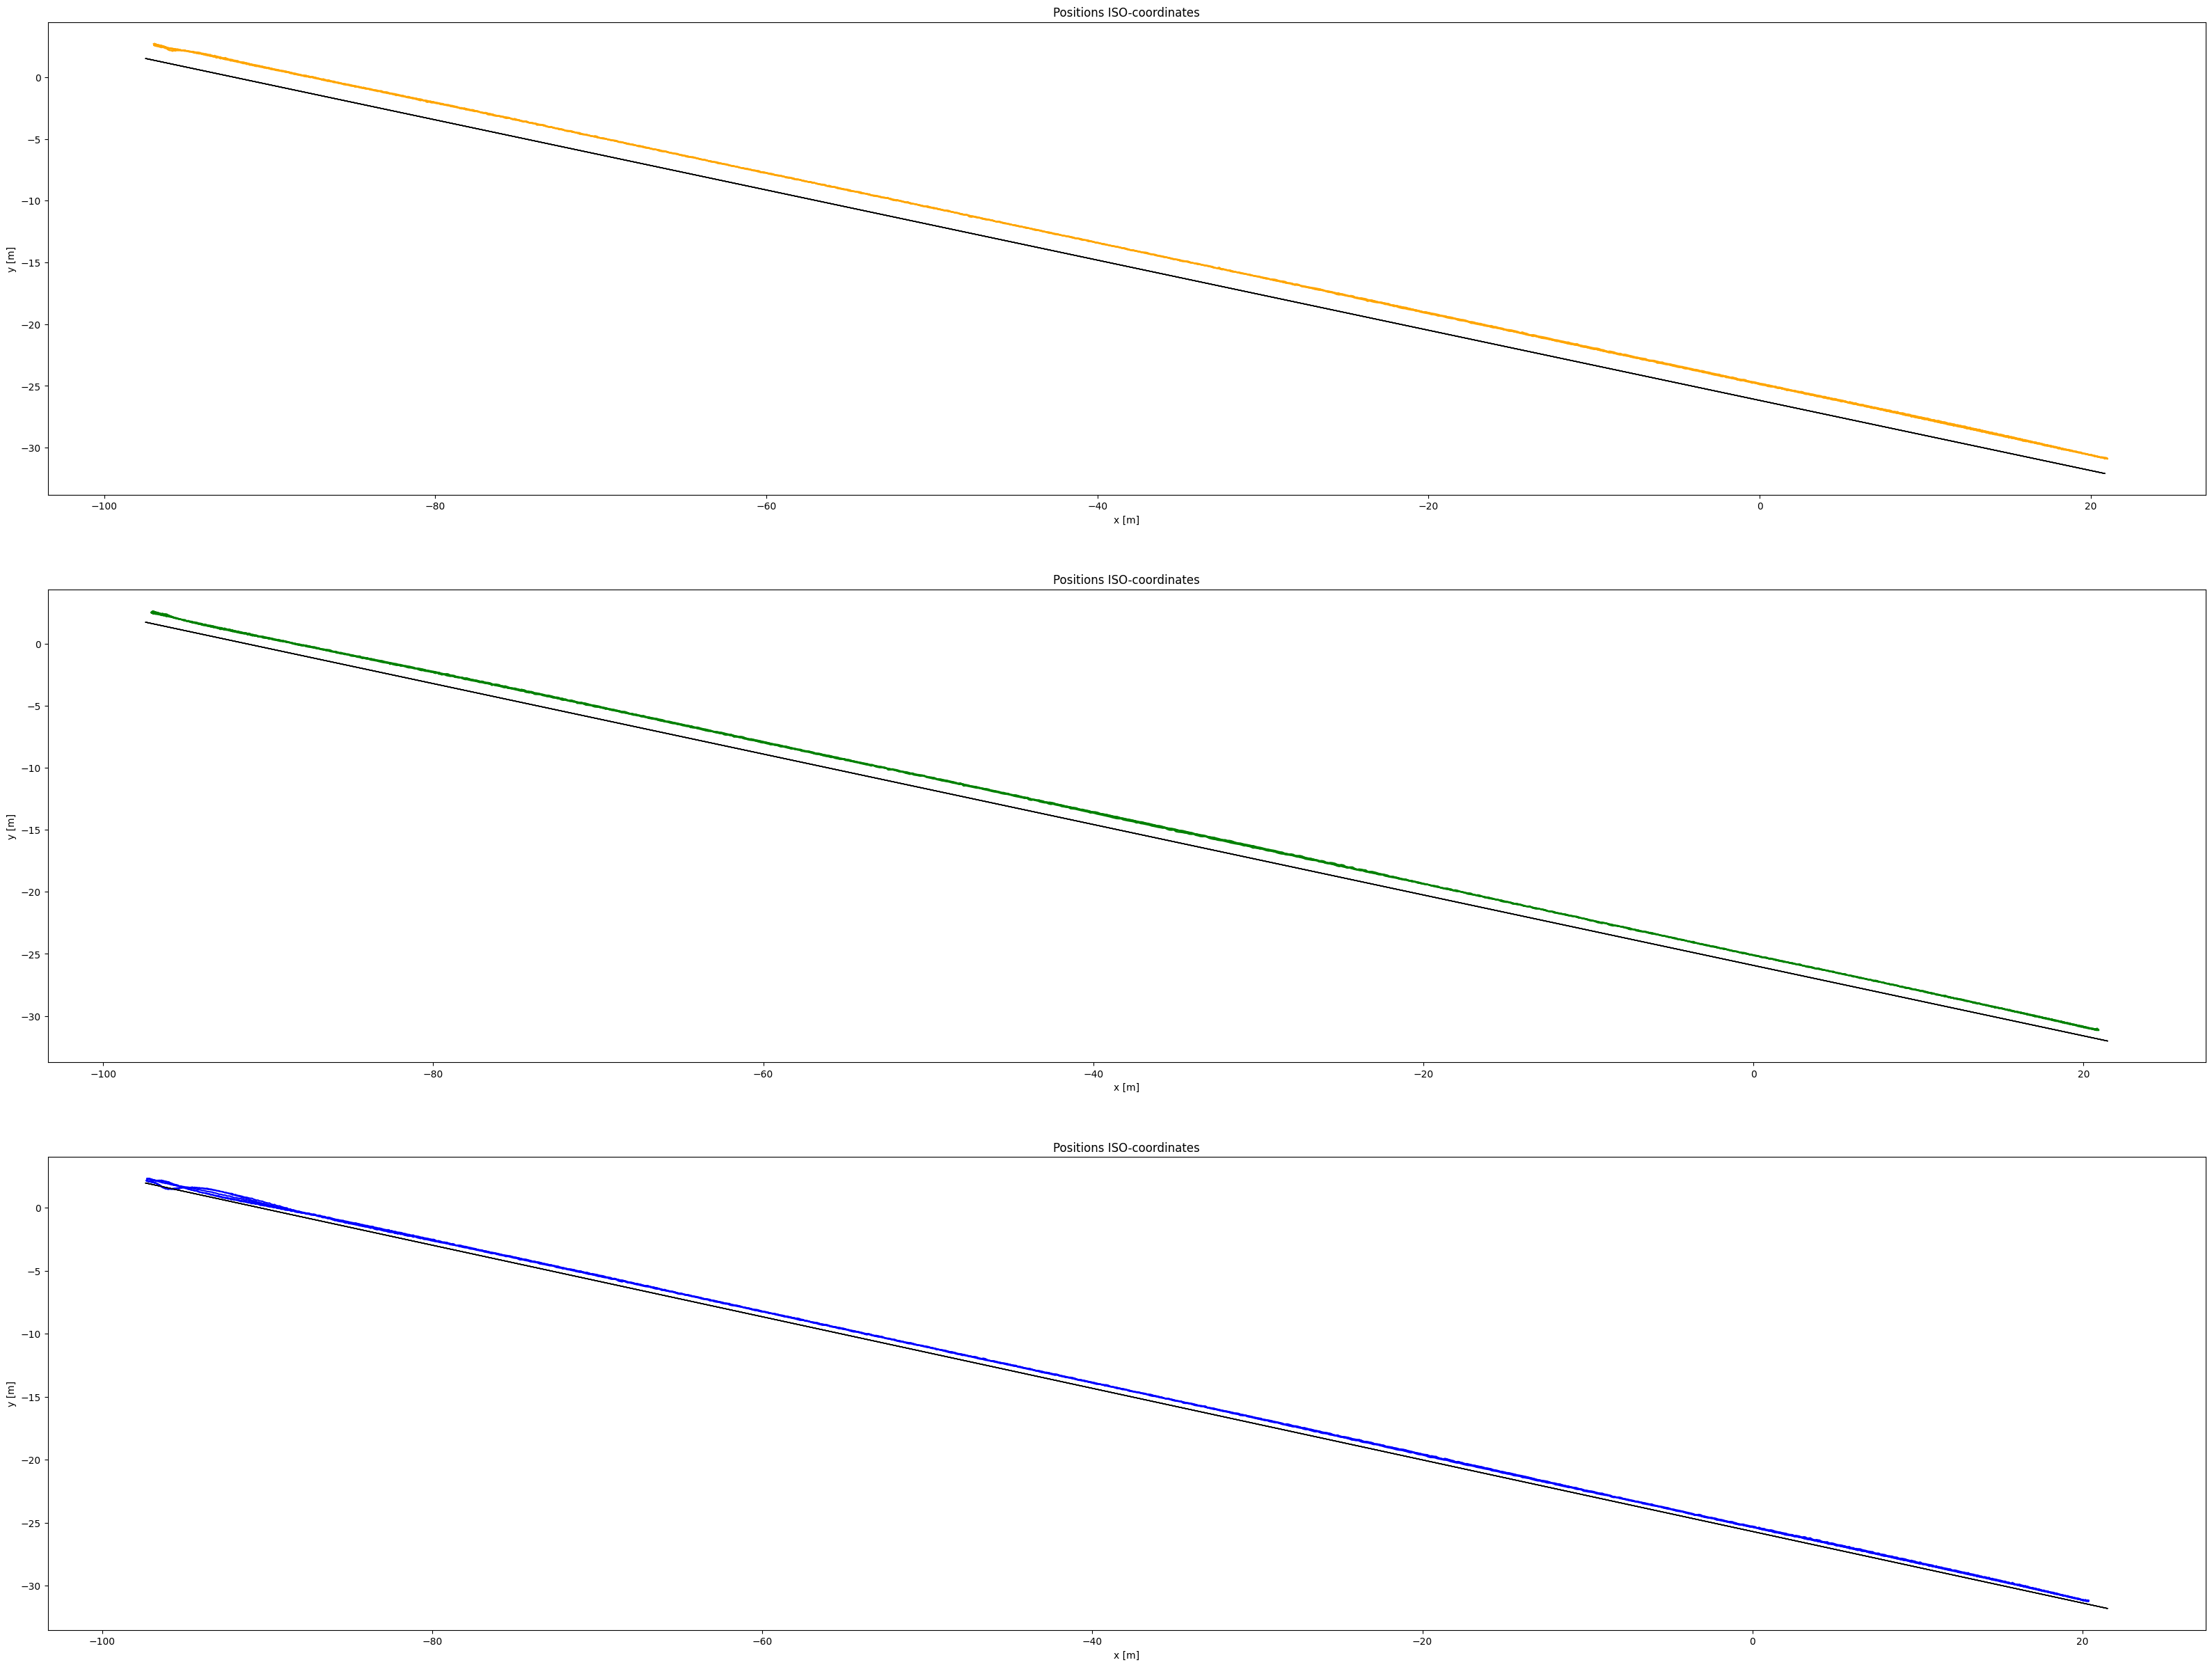

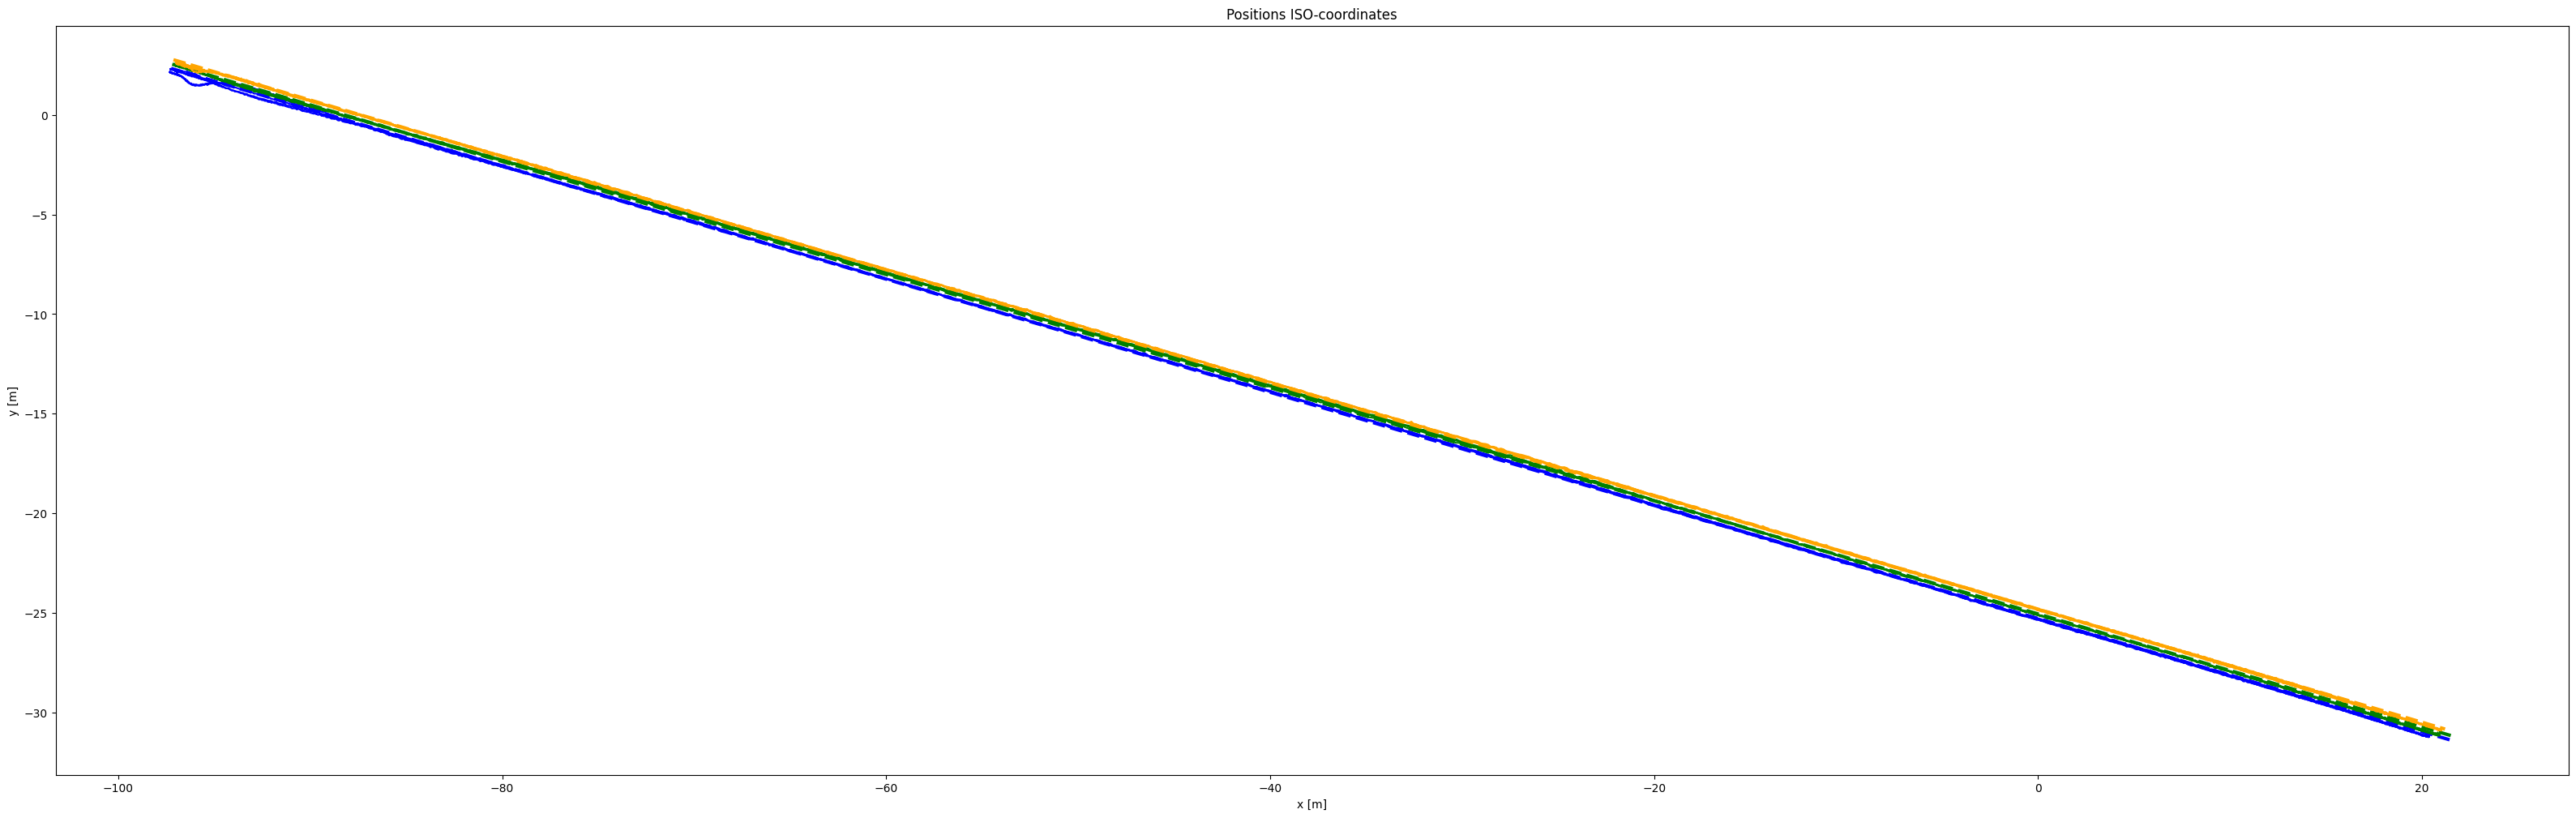

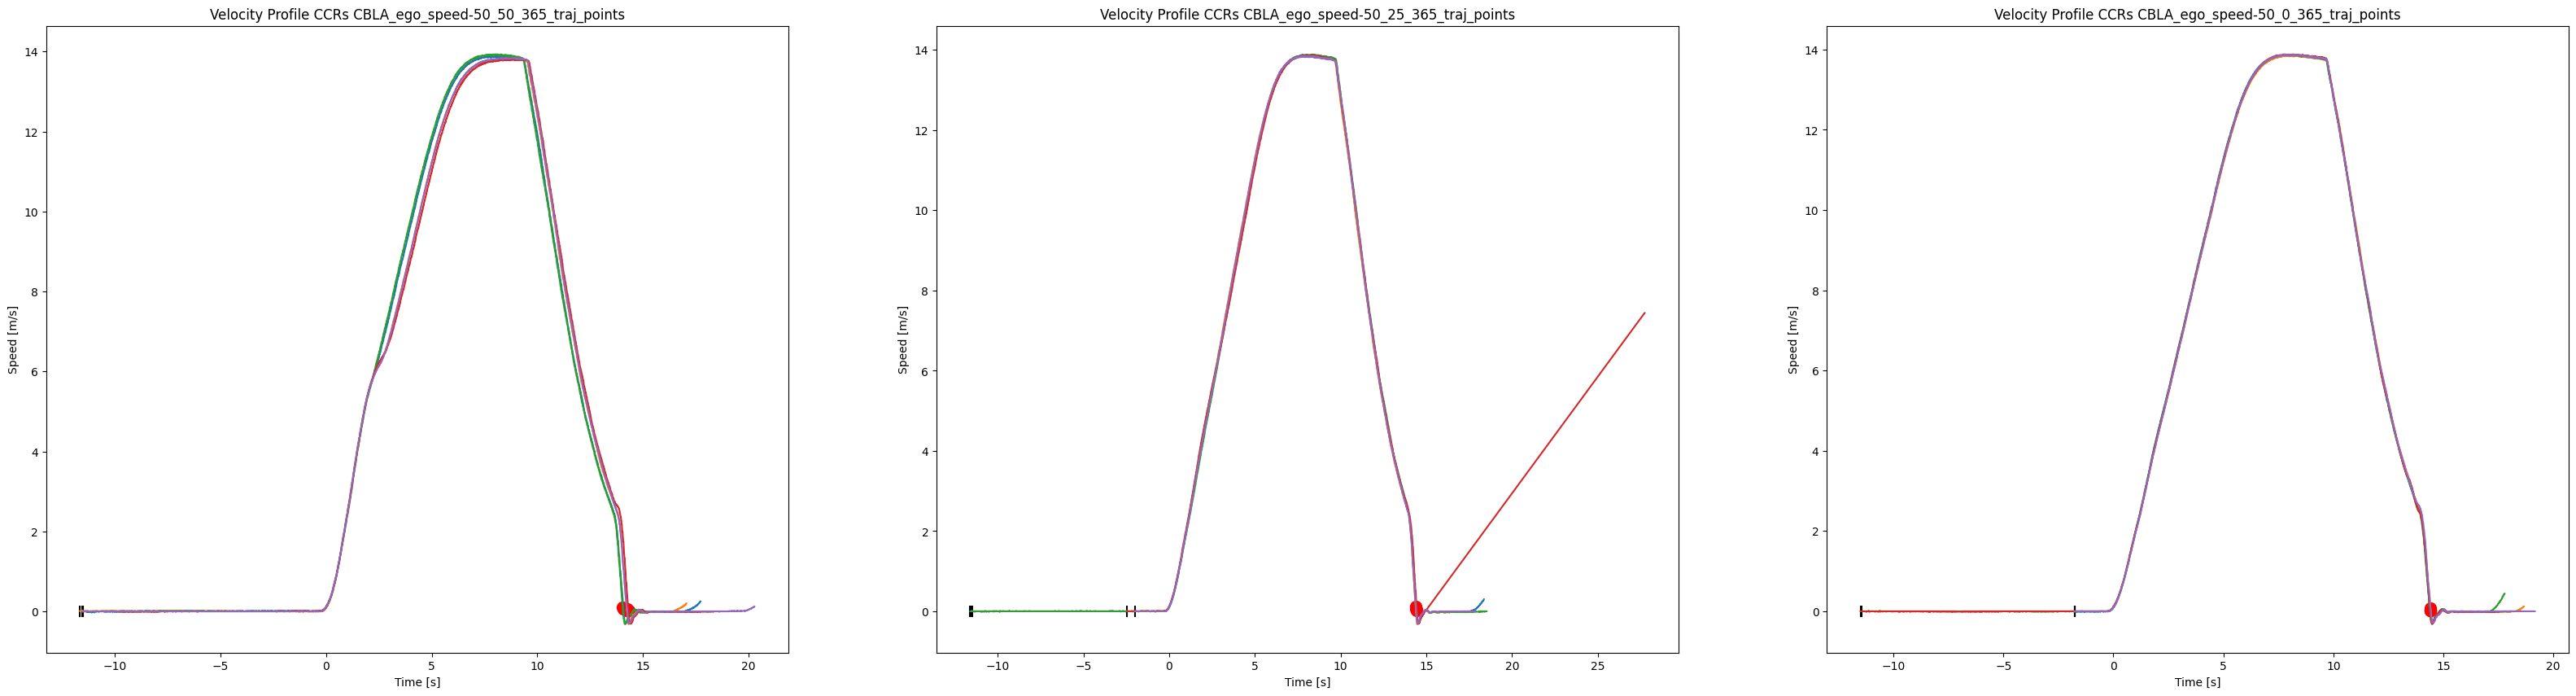

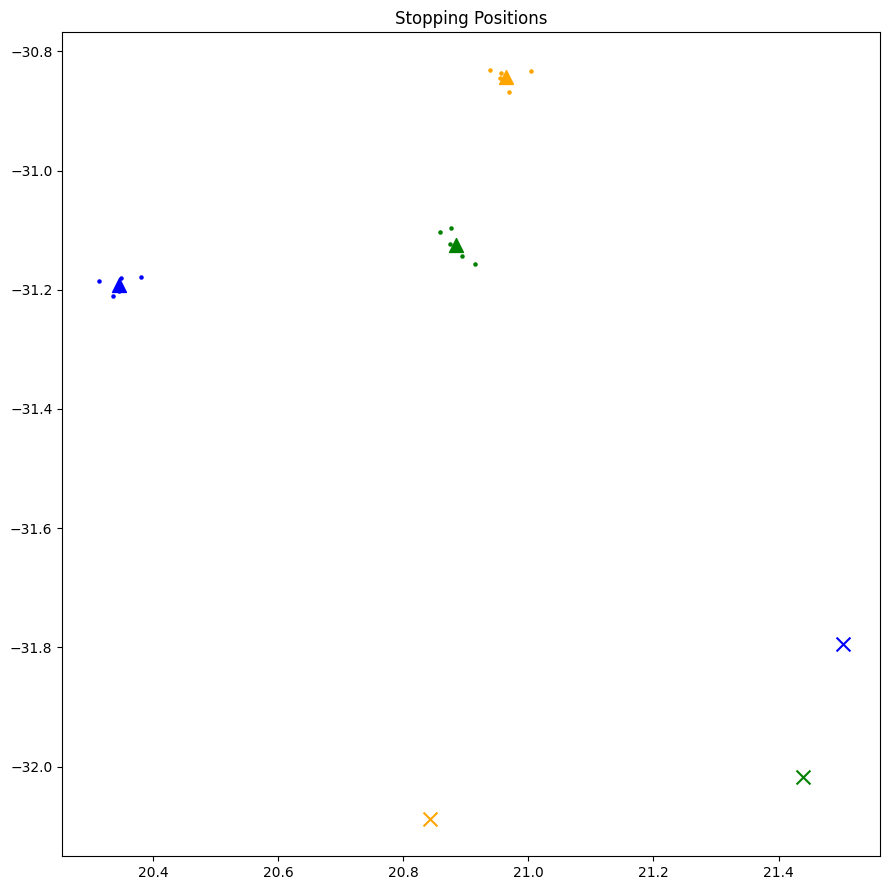

In [83]:
# %matplotlib tk
%matplotlib inline

dir_path = 'logs/CBLA'
paths = os.listdir(dir_path)[::-1]
print(paths)
#flip the order of the paths
colours = ['blue', 'green', 'orange']

_, (ax_position_0, ax_position_25, ax_position_50) = plt.subplots(3, 1, figsize=(40,30))
_, (ax_position_all_offset) = plt.subplots(1, 1, figsize=(40,12))

_, (ax_vel_50, ax_vel_25, ax_vel_0) = plt.subplots(1, 3, figsize=(40,10))
# Put into list
ax_position_all = [ax_position_50, ax_position_25, ax_position_0]
ax_test_velocities = [ax_vel_50, ax_vel_25, ax_vel_0]

fig_stopping_positions = plt.figure(figsize=(9,9))
ax_stopping_positions = fig_stopping_positions.add_subplot(111)
ax_stopping_positions.set_title('Stopping Positions')

traj_files = ['logs/traj/CBLA/mondeo_0.traj', 'logs/traj/CBLA/mondeo_25.traj', 'logs/traj/CBLA/mondeo_50.traj']
for index, traj_file in enumerate(traj_files):
  traj = get_atos_traj(traj_file)

  ax_stopping_positions.scatter(traj['x'].iloc[-1], traj['y'].iloc[-1], color=colours[index], s=100, marker='x') # Traj end point

  m_values = []
  c_values = []

for index, directory in enumerate(paths):

  traj = get_atos_traj(traj_files[index])

  m_vals_test = []
  c_vals_test = []

  x_values = []
  y_values = []

  time_durations = []
  distances_to_path = []
  
  for file_path in os.listdir(os.path.join(dir_path, directory)):
    file_path = os.path.join(dir_path, directory, file_path)
    df_all = log_to_df(file_path)
    df = df_all[df_all['client_id'] == 1]
    df.reset_index(drop=True, inplace=True)
    start_timestamp = df[df['ready'] == 'RUNNING'].iloc[0]['timestamp']

    # Fig 1: Position
    plot_obj_trajs(df, ax_position_all_offset, colours[index])
    plot_obj_trajs(df, ax_position_all[index], colours[index])
    ax_position_all[index].plot(traj['x'], traj['y'], color='black', linewidth=1, linestyle='-')

    # Fig 2: Velocities
    plot_velocities(df, ax_test_velocities[index], True)
    ax_test_velocities[index].set_title('Velocity Profile CCRs {}'.format(directory))

    # Fig 3: Stopping positions
    x, y, stopping_timestamp = get_stopping_position(df)
    ax_stopping_positions.scatter(x, y, s=5, color=colours[index], label=directory)
    
    # Statistics for stopping positions
    x_values.append(x)
    y_values.append(y)
    time_durations.append(stopping_timestamp - start_timestamp)
    # start_timestamp_index = df.index[df['timestamp'] == start_timestamp]

    start_time = df['timestamp'][int(len(df) * 0.60)]
    start_timestamp_index = df[df['timestamp'] == start_time].index[0]

    # stopping_timestamp_index = df.index[df['timestamp'] == stopping_timestamp]
    last_quarter = df['speed_lon'][int(len(df) * 0.75):]
    # Get idx where the positive to negative transition happens
    stopping_timestamp_index = np.where(np.diff(np.sign(last_quarter)))[0][0] + int(len(df) * 0.75)
    
    distances_to_path.append(get_average_distance_vehicle_to_path(df.iloc[start_timestamp_index:stopping_timestamp_index], traj))

    # Line equation for paths: y = mx + c
    m = (traj['y'].iloc[-1] - traj['y'].iloc[0]) / (traj['x'].iloc[-1] - traj['x'].iloc[0])
    c = traj['y'].iloc[-1] - m * traj['x'].iloc[-1]
  
  x_start, x_end = traj['x'][0], traj['x'].iloc[-1]
  y_start, y_end = traj['y'][0], traj['y'].iloc[-1]
  angle = np.arctan2(y_end - y_start, x_end - x_start)
  traj_offset = offset_traj(traj, distances_to_path[index], np.rad2deg(angle) + 90)
  ax_position_all_offset.plot(traj_offset['x'], traj_offset['y'], color=colours[index], linewidth=3, linestyle='--')

  
  m_values.append(m)
  c_values.append(c)
    
  ax_stopping_positions.scatter(np.mean(x_values), np.mean(y_values), s=100, color=colours[index], marker='^', label=directory)
  print(f'Test: {directory} \tMean stopping position: ({np.mean(x_values):.2f}, {np.mean(y_values):.2f}) \tStandard deviation: ({np.std(x_values):.2f}, {np.std(y_values):.2f})')                                         
  print(f'Distance from mean to last traj point: {np.linalg.norm([np.mean(x_values) - traj["x"].iloc[-1], np.mean(y_values) - traj["y"].iloc[-1]]):.2f}')
  print(f'Mean time duration: {np.mean(time_durations):.2f} \tStandard deviation: {np.std(time_durations):.2f}')
  print(f'Mean distance to path: {np.mean(distances_to_path):.2f} \tStandard deviation: {np.std(distances_to_path):.2f}')
  print(f'Offset error: {np.linalg.norm([m_values[0] - m_values[-1], c_values[0] - c_values[-1]])-0.436*index}')
  print()

  
plt.tight_layout()
plt.show()